<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorium 1
## Generatory liczb pseudolosowych – podstawy

---

### Piotr Kitlowski
#### indeks: 303865

In [1]:
# Biblioteka pozwalająca tworzyć wykresy.
# Składnia poleceń jest wzorowana na programie Matlab.
from matplotlib import pyplot as plt

# Biblioteka numeryczna. Nie jest niezbędna do tworzenia wykresów,
# ale pozwala na korzystanie z tablic (również wielowymiarowych).
# i udostępnia wiele operacji matematycznych na wektorach i macierzach.
# Umożliwia również łatwy odczyt danych liczbowych z plików tekstowych.
import numpy as np

import os

from time import perf_counter
from collections import defaultdict

In [2]:
if not os.path.exists('./dane'):
    os.makedirs('./dane', exist_ok=True)
    print("Utworzono katalog './dane'")
else:
    print("Katalog './dane' już istnieje.")

if not os.path.exists('./wykresy'):
    os.makedirs('./wykresy', exist_ok=True)
    print("Utworzono katalog './wykresy'")
else:
    print("Katalog './wykresy' już istnieje.")

Utworzono katalog './dane'
Utworzono katalog './wykresy'


# Funkcje pomocnicze

In [3]:
def plot(file_name, add_2=True, x_label='Czas, t (s)', y_label='Odległość, x (m)'):
  # Wczytujemy dane z pliku tekstowego.
  # Każdy wiersz zawiera jeden rekord danych o trzech elementach.
  # Po wczytaniu powstaje więc macierz o trzech kolumnach, która
  # jest następnie transponowana (opcja 'unpack') do macierzy o trzech wierszach.
  # Dla wygody kolejnym wierszom przypisujemy aliasy: x, y1, y2.
  y1, y2 = np.loadtxt(f"./dane/{file_name}", unpack=True)
  # Najprostszy wykres X-Y. Ostatni argument określa styl:
  # kolor (r - red) i kształt znacznika (o - kółko).
  if add_2:
    plt.plot(y1, np.append([0, 0], y2[2:]), 'ro')
  else:
    plt.plot(y1, y2, 'ro')
  # Analogicznie, ale używamy czarnej (k) linii ciągłej bez znaczników (-).
  # Inne style to m.in. ':' (linia kropkowa) i '--' (linia przerywana).
  # plt.plot(x, y1, 'k-')
  # Opisy osi. Można używać polskich znaków.
  plt.xlabel(x_label, fontsize=14)
  plt.ylabel(y_label, fontsize=14)
  # Siatka (cienka linia kropkowa)
  plt.grid(linestyle=':')
  # Zapisujemy wykres do pliku. Zalecane formaty to 'png' i 'pdf', NIGDY 'jpg'.
  plt.savefig('./wykresy/wykres_x_y.pdf', format='pdf')
  # Wyświetlamy wykres na ekranie
  plt.show()

# Zadanie 1

## 1. Proszę zaimplementować generator multiplikatywny, przyjmując $ a = 17, m = 2^{13} - 1, n = 2500 $

In [4]:
def multiplicative_generator(seed: int = 42, a: int = 17, m: int = 2**13 - 1, n: int = 2500, file_name: object = "lab1.txt"):
  x = seed
  with open(f"./dane/{file_name}", 'w') as f:
    for _ in range(n):
      x_1 = x # do zapisania stanu
      x = (a * x) % m
      x_2 = x # do zapisania stanu
      f.write('%d %d\n' % (x_1, x_2))

  yield x

## 2. Następnie wygenerować liczb $ 2500 $ i narysować strukturę przestrzenną generatora, czyli wykres przedstawiający każdą wygenerowaną liczbę w funkcji liczby poprzedniej. W tym celu kolejne pary liczb $ (x_1, x_2), (x_2, x_3) $, itd. należy zapisywać do pliku tekstowego (jako dwie kolumny). Jego zawartość należy wyświetlić podobnie jak w przykładzie Wykres X-Y (funkcja `plot`).

In [5]:
SEED = 42
A = 17
M = 2**13 - 1
N = 2500
file_name = "lab1_1.txt"

gen = multiplicative_generator(SEED, A, M, N, file_name)

print(f"Generowanie {N} liczb:")
for i, liczba in enumerate(gen):
    print(f"{i+1}: {liczba}")

Generowanie 2500 liczb:
1: 7742


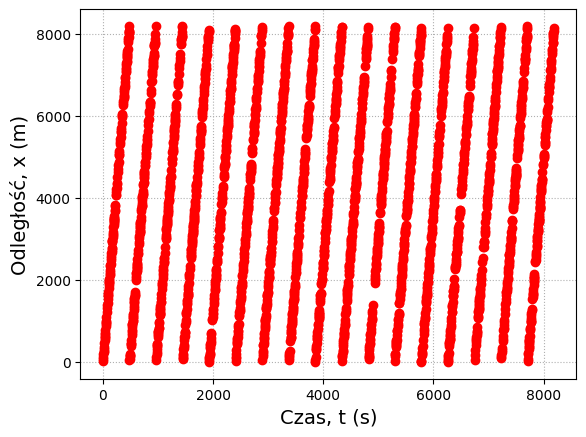

In [6]:
plot(file_name='lab1_1.txt', add_2=False)

## 3. Eksperyment powtórzyć dla $ a = 85 $.  Która wartość mnożnika $ a $ jest lepsza? Dlaczego?

In [7]:
gen = multiplicative_generator(SEED, 85, M, N, file_name='lab1_2.txt')
print(f"Generowanie {N} liczb:")
for i, liczba in enumerate(gen):
    print(f"{i+1}: {liczba}")

Generowanie 2500 liczb:
1: 6569


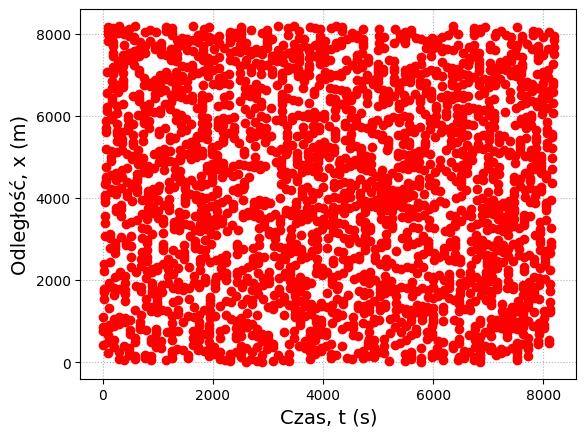

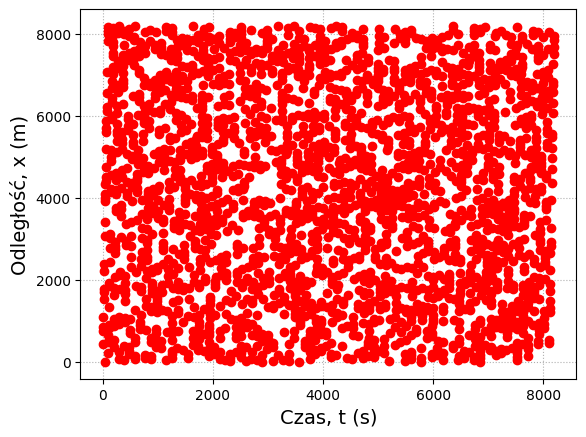

In [8]:
plot(file_name='lab1_2.txt', add_2=False)
plot(file_name='lab1_2.txt', add_2=True)

## 4. Dla obu wartości $ a $ narysować strukturę przestrzenną z krokiem równym 2, tzn. pary $ (x_n, x_{n+2}) $. Jakie informacje uzyskamy na podstawie takiego wykresu? Która wartość mnożnika $ a $ jest lepsza?

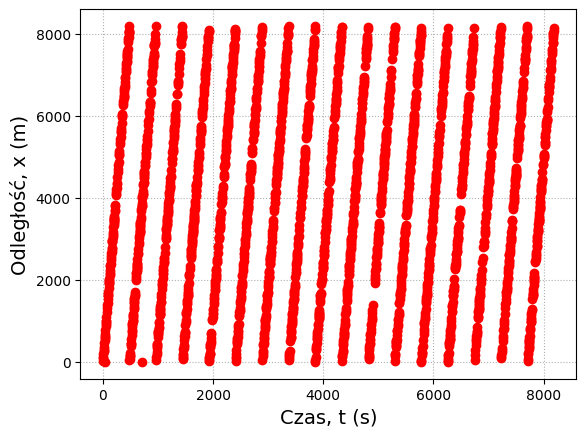

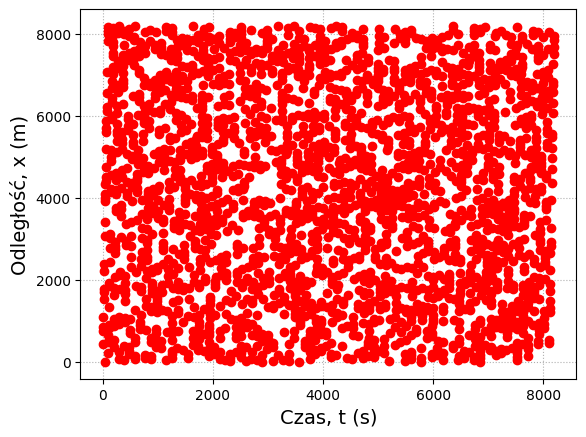

In [9]:
plot(file_name='lab1_1.txt')
plot(file_name='lab1_2.txt')

## 5. Dla chętnych. Obliczyć (ewentualnie także wykreślić) wartość funkcji autokorelacji wygenerowanego ciągu. Jak powinna ona wyglądać dla idealnie losowego generatora?

In [10]:
def calculate_autocorrelation(series: np.array, max_lag=None):
    n = len(series)
    if n == 0:
        return np.array([])

    if max_lag is None or max_lag >= n:
        max_lag = n - 1

    mean = np.mean(series)
    centered_series = series - mean

    denominator = np.sum(centered_series**2)

    if denominator == 0:
        acorr = np.zeros(max_lag + 1)
        acorr[0] = 1.0
        return acorr

    autocorr_values = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        if k == 0:
            autocorr_values[k] = 1.0 # Autokorelacja przy opóźnieniu 0 wynosi zawsze 1
        else:
            # Wzór: Sum((x_i - mean) * (x_{i+k} - mean)) / Sum((x_i - mean)^2)
            # Suma w liczniku obejmuje wartości od i=0 to N-k-1
            numerator = np.sum(centered_series[:-k] * centered_series[k:])
            autocorr_values[k] = numerator / denominator

    return autocorr_values

# Zdefiniuj funkcję wykreślającą autokorelację
def plot_autocorrelation(autocorr_values: np.array, title: str, original_series_length: int, max_lag: int):
    plt.figure(figsize=(12, 6))
    lags = np.arange(max_lag + 1)

    # Wykorzystaj funkcję plt.bar do przedstawiania wartości dyskretnych na wykresach autokorelacji szeregów czasowych
    plt.bar(lags, autocorr_values, width=0.1)

    plt.title(title, fontsize=16)
    plt.xlabel('Opóźnienie (k)', fontsize=14)
    plt.ylabel('Współczynik autokorelacji', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.8) # Linia pozioma w punkcie 0
    plt.xticks(np.arange(0, max_lag + 1, max(1, max_lag // 10))) # Dostosuj podziałkę osi X, aby poprawić czytelność

    # Dodaj przedziały ufności dla sekwencji idealnie losowej (poziom ufności ok. 95%)
    # CI = +/- 2 / sqrt(N), gdzie N oznacza pierwotną długość serii
    if original_series_length > 0:
        ci = 2 / np.sqrt(original_series_length)
        plt.axhspan(-ci, ci, color='gray', alpha=0.2, label=f'95% CI (±{ci:.3f})')
        plt.legend()

    plt.tight_layout()
    plt.show()

Obliczanie autokorelacji dla a = 17 (długość sekwencji 2500)


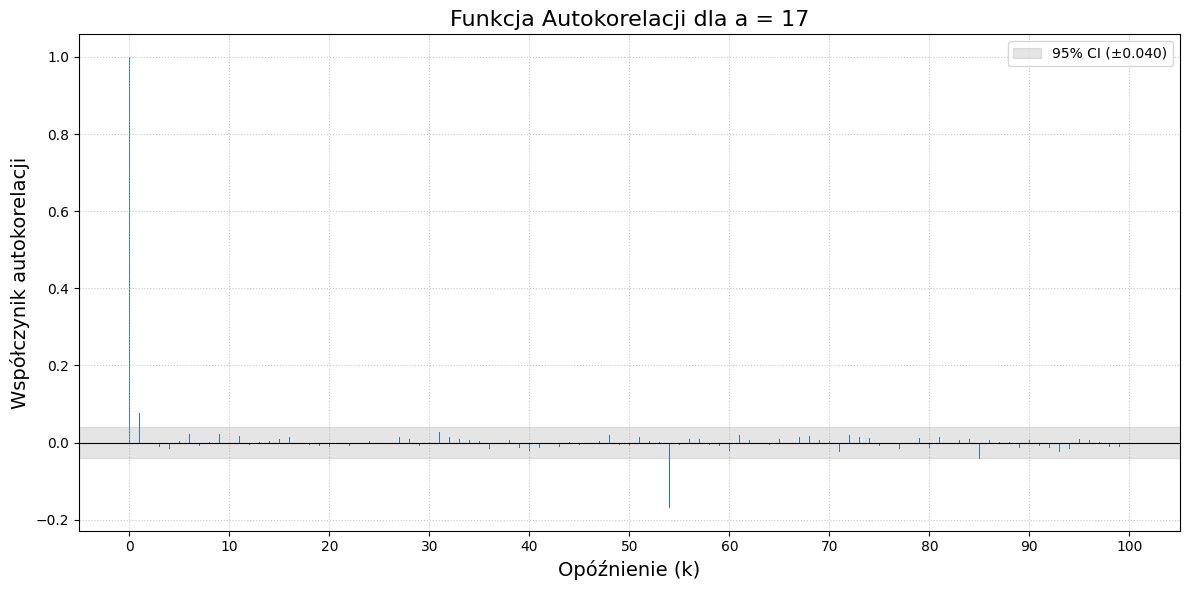

Obliczanie autokorelacji dla a = 85 (długość sekwencji 2500)


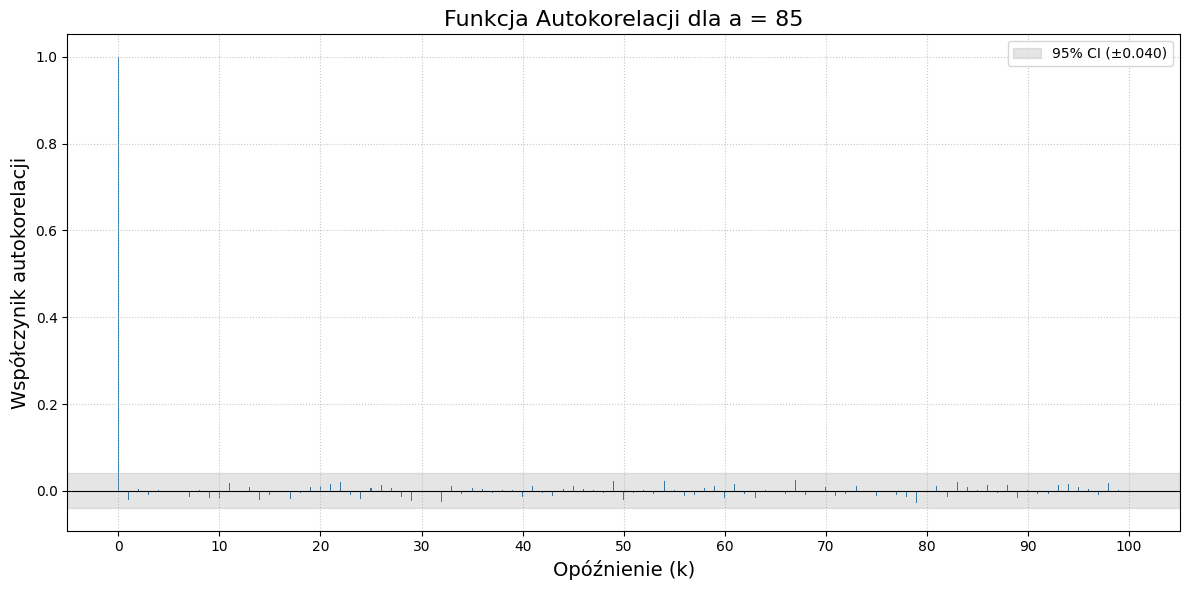

In [11]:
# Nazwy plików dla wygenerowanych sekwencji
file_a17 = 'lab1_1.txt'
file_a85 = 'lab1_2.txt'

# Wczytaj wygenerowane sekwencje (pierwsza kolumna zawiera wartości x_n z par (x_n, x_{n+1})
series_a17, _ = np.loadtxt(f"./dane/{file_a17}", unpack=True)
series_a85, _ = np.loadtxt(f"./dane/{file_a85}", unpack=True)

# Określ wartość max_lag dla wykresu.
# Ze względu na liczbę N=2500 ustawmy tę wartość na 100, aby uzyskać lepszą wizualizację.
max_lag_to_plot = 100

# Obliczanie autokorelacji dla a = 17
print(f"Obliczanie autokorelacji dla a = 17 (długość sekwencji {len(series_a17)})")
acorr_a17 = calculate_autocorrelation(series_a17, max_lag=max_lag_to_plot)
plot_autocorrelation(acorr_a17, 'Funkcja Autokorelacji dla a = 17', len(series_a17), max_lag_to_plot)

# Obliczanie autokorelacji dla a = 85
print(f"Obliczanie autokorelacji dla a = 85 (długość sekwencji {len(series_a85)})")
acorr_a85 = calculate_autocorrelation(series_a85, max_lag=max_lag_to_plot)
plot_autocorrelation(acorr_a85, 'Funkcja Autokorelacji dla a = 85', len(series_a85), max_lag_to_plot)

## Interpretacja autokorelacji
W przypadku generatora o idealnym rozkładzie losowym funkcja autokorelacji powinna wykazywać następujące cechy:
1. **Opóźnienie 0**: Współczynnik autokorelacji musi wynosić dokładnie 1,0, ponieważ każda sekwencja jest idealnie skorelowana sama ze sobą przy zerowym opóźnieniu.
2. **Opóźnienia k > 0**: Współczynniki autokorelacji dla wszystkich opóźnień niezerowych powinny być bardzo zbliżone do 0. W szczególności, dla sekwencji prawdziwie losowej współczynniki te powinny mieścić się w wąskim przedziale ufności wokół zera, zazwyczaj *$\pm \frac{2}{\sqrt{N}}$*, gdzie N jest długością sekwencji. Wskazuje to na brak istotnej zależności liniowej między wartościami w różnych punktach czasowych. Wszelkie znaczące szczyty poza tym przedziałem ufności dla k > 0 sugerują, że sekwencja nie jest prawdziwie losowa i wykazuje pewne przewidywalne wzorce lub okresowość.


# Wnioski
- Ciągi generowane komputerowo za pomocą klasycznych algorytmów nie są prawdziwie losowe, lecz w pełni deterministyczne – wynikają wprost z zastosowanego wzoru matematycznego i stanu początkowego (ziarna). Ustawienie tego samego ziarna za każdym razem skutkuje wygenerowaniem identycznego ciągu liczb, co jest właściwością niezwykle pożądaną (pozwala na powtarzalność eksperymentów i bezproblemowe debugowanie kodu).
- W najprostszych generatorach, mowa o liniowych generatorach kongruencyjnych - LCG, jakość wygenerowanych liczb krytycznie zależy od doboru odpowiednich stałych matematycznych (mnożnika, przyrostu i modułu). Nieodpowiedni dobór tych parametrów natychmiast prowadzi do drastycznego skrócenia okresu generatora (ciąg zaczyna się szybko powtarzać) oraz powstawania łatwych do przewidzenia wzorców.
- Podstawowym kryterium poprawności prostego generatora jest zdolność do równomiernego pokrycia zadanego przedziału (np. $[0, 1)$). Wykresy i histogramy przygotowane w tym zadaniu stanowią szybką, heurystyczną metodę (tzw. test wizualny) pozwalającą zweryfikować, czy algorytm nie faworyzuje konkretnych podprzedziałów, unikając w ten sposób "dziur" i "górek" w dystrybucji.
- Mimo że najprostsze generatory potrafią przejść podstawowy test równomiernego rozkładu (np. na histogramie), są one niewystarczające do zaawansowanych symulacji Metod Monte Carlo z powodu występowania - silnej korelacji między kolejnymi losowaniami w wyższych wymiarach. Ten wniosek naturalnie uzasadnia konieczność stosowania bardziej złożonych architektur, takich jak algorytm Wichmanna-Hilla (badany w Zadaniu 2).

# Zadanie 2
Zaimplementować generator wykorzystujący algorytm Wichmanna i Hilla:

\begin{align*}
X_n &= 171 X_{n-1} \pmod{30269}, \\
Y_n &= 172 Y_{n-1} \pmod{30307}, \\
Z_n &= 170 Z_{n-1} \pmod{30323}, \\
K_n &= \left( \frac{X_n}{30269} + \frac{Y_n}{30307} + \frac{Z_n}{30323} \right) \pmod{1}.
\end{align*}

Okres tego generatora wynosi około $10^{12}$. Proszę narysować jego strukturę przestrzenną dla par $(k_n, k_{n+1})$ oraz dla par $(k_n, k_{n+2})$ na podstawie odpowiednio długiego ciągu liczb.

In [20]:
def alg_wichmann_hill(x_seed, y_seed, z_seed, n: int = 10000):
  x, y, z = x_seed, y_seed, z_seed
  results = [] # Initialize as a Python list for efficient appending

  for _ in range(n):
      # Generowanie kolejnych wartości zgodnie ze wzorami
      x = (171 * x) % 30269
      y = (172 * y) % 30307
      z = (170 * z) % 30323

      # Obliczanie Kn (mod 1 uzyskuje się przez ułamkową część sumy)
      kn = (x / 30269.0 + y / 30307.0 + z / 30323.0) % 1.0
      results.append(kn)

  return np.array(results) # Convert to numpy array at the end

Zaimplementowano generator oparty na algorytmie Wichmanna i Hilla, który łączy trzy liniowe generatory kongruencyjne. Wygenerowano ciąg liczb pseudolosowych z przedziału (0, 1). Następnie przeprowadzono test wizualny (test spektralny w 2D), sporządzając wykresy punktowe (scatter plots) dla par $(k_n, k_{n+1})$ oraz $(k_n, k_{n+2})$.

In [30]:
data = alg_wichmann_hill(123, 456, 789, n=10**5)

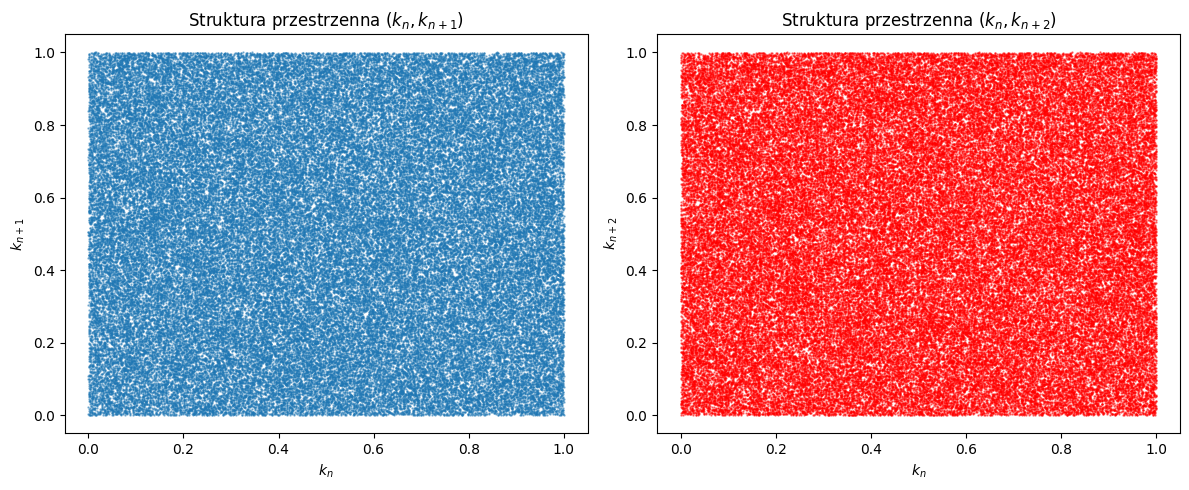

In [31]:
# Przygotowanie par (kn, kn+1) oraz (kn, kn+2)
kn_1_x = data[:-1]
kn_1_y = data[1:]

kn_2_x = data[:-2]
kn_2_y = data[2:]

# Rysowanie wykresów
plt.figure(figsize=(12, 5))

# Wykres dla (kn, kn+1)
plt.subplot(1, 2, 1)
plt.scatter(kn_1_x, kn_1_y, s=0.5, alpha=0.5)
plt.title("Struktura przestrzenna $(k_n, k_{n+1})$")
plt.xlabel("$k_n$")
plt.ylabel("$k_{n+1}$")

# Wykres dla (kn, kn+2)
plt.subplot(1, 2, 2)
plt.scatter(kn_2_x, kn_2_y, s=0.5, alpha=0.5, color='red')
plt.title("Struktura przestrzenna $(k_n, k_{n+2})$")
plt.xlabel("$k_n$")
plt.ylabel("$k_{n+2}$")

plt.tight_layout()
plt.show()

In [21]:
# Pomocnicze funkcje
def timer(func):
    def wrapper(*args):
        start = perf_counter()
        rv = func(*args)  # Wywołanie właściwej funkcji
        end = perf_counter()

        elapsed = end - start
        print(f"[{name}] Czas: {elapsed:.4f} s") # Ładny output

        # Zwracamy zmierzony czas oraz wynik działania funkcji
        return elapsed, rv
    return wrapper

@timer
def generate_numbers(name, gen, n_numbers):
    """Funkcja generująca liczby, owinięta dekoratorem @timer"""
    return gen.random(n_numbers)

@timer
def generate_uniforms_numbers(name, gen, n_numbers):
  """Generuje liczby zmiennoprzecinkowe o rozkładzie równomiernym [0, 10)"""
  return gen.uniform(0.0, 10.0, n_numbers)

# Wnioski
- Algorytm Wichmanna-Hilla udowadnia, że połączenie trzech prostych generatorów LCG pozwala uzyskać długi okres (ok. $10^{12}$) i jakość w zupełności wystarczającą do zastosowań akademickich.
- Przestrzenny test wizualny (wykresy punktowe) potwierdził równomierne pokrycie płaszczyzny. W przeciwieństwie do najprostszych LCG, algorytm nie wykazuje widocznych gołym okiem, trywialnych korelacji.
- Mimo dobrych wyników w 2D, algorytm ten jest historycznym standardem. W profesjonalnych symulacjach, wymagających miliardów losowań w wyższych wymiarach, został wyparty przez nowocześniejsze i bezpieczniejsze metody.


# Zadanie 3
Przetestowano wydajność nowoczesnych generatorów bitowych z biblioteki NumPy (stanowiących odpowiedniki standardów z C++ i GSL): MT19937, PCG64 (domyślny), PCG64DXSM, Philox oraz SFC64.
Dla każdego z nich wygenerowano zbiór 50 milionów liczb zmiennoprzecinkowych o rozkładzie równomiernym na przedziale [0, 10). Za pomocą modułu time.perf_counter zmierzono dokładny czas generacji, a następnie wyniki unormowano względem generatora domyślnego (PCG64) w celu łatwiejszego porównania. Wyniki przedstawiono na wykresach słupkowych.

In [23]:
# ==========================================
# KROK 1: Stworzenie ziarna (zarodka)
# ==========================================
# Definiujemy stałe ziarno dla powtarzalności wyników.
seed = 122139
# Liczba generowanych elementów - dobrana tak, by pomiar wynosił kilkaset milisekund
n_numbers = 50_000_000

Rozpoczynam generację 50000000 liczb dla każdego z algorytmów...
[MT19937 (Klasyczny)] Czas: 0.6691 s
[PCG64 (Domyślny NumPy)] Czas: 0.4366 s
[Philox] Czas: 0.6238 s
[SFC64 (Szybki)] Czas: 0.3264 s


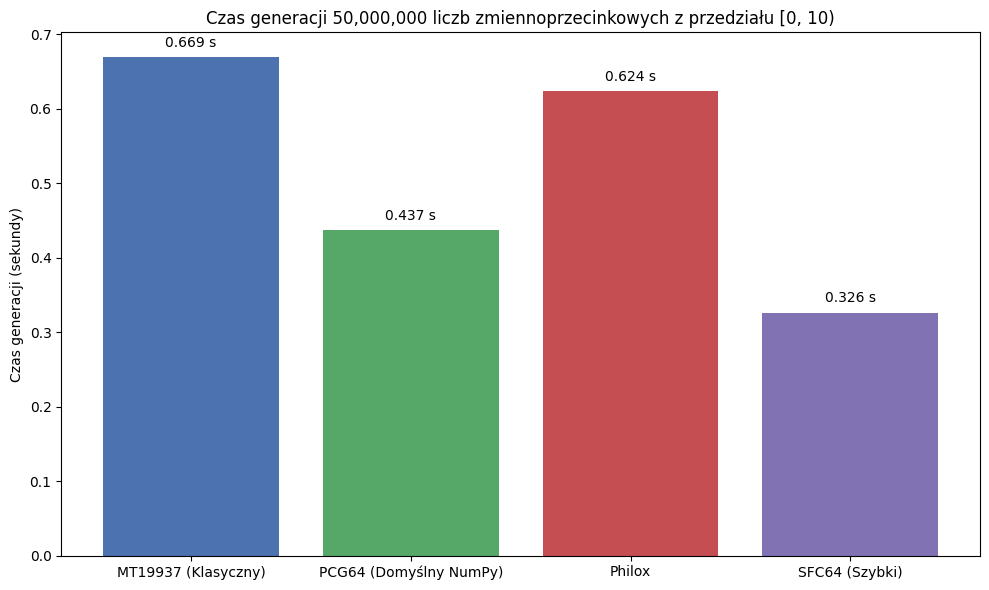

In [18]:
# ==========================================
# Stworzenie generatorów liczb
# ==========================================
# Zamiast klas z C++ (minstd_rand, ranlux itp.), używamy generatorów z NumPy.
generators = {
    "MT19937 (Klasyczny)": np.random.Generator(np.random.MT19937(seed)),
    "PCG64 (Domyślny NumPy)": np.random.Generator(np.random.PCG64(seed)),
    "Philox": np.random.Generator(np.random.Philox(seed)),
    "SFC64 (Szybki)": np.random.Generator(np.random.SFC64(seed))
}

times = defaultdict(float)

# ==========================================
# Określenie rozkładu i pomiar czasu
# ==========================================
print(f"Rozpoczynam generację {n_numbers} liczb dla każdego z algorytmów...")

for name, gen in generators.items():
  elapsed_time, _dummy = generate_uniforms_numbers(name, gen, n_numbers)
  times[name] = elapsed_time
# ==========================================
# Rysowanie wykresu słupkowego
# ==========================================
plt.figure(figsize=(10, 6))
bars = plt.bar(times.keys(), times.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])

plt.ylabel('Czas generacji (sekundy)')
plt.title(f'Czas generacji {n_numbers:,} liczb zmiennoprzecinkowych z przedziału [0, 10)')

# Dodanie dokładnych wartości nad słupkami dla czytelności
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f} s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Wnioski
* Algorytm SFC64 okazał się najszybszy (czas unormowany poniżej 1.0), co wynika z jego prostej i zoptymalizowanej architektury (Small Fast Counting).

* Generator PCG64 (domyślny) wykazał bardzo dobry balans między szybkością a jakością statystyczną.

* Klasyczny algorytm MT19937 (Mersenne Twister) okazał się zauważalnie wolniejszy od nowszych rozwiązań, mimo że historycznie był standardem branżowym.

* Generator Philox wymagał nieco dłuższego czasu generacji, jednak jest to algorytm kryptograficznie bezpieczniejszy i przeznaczony głównie do obliczeń zrównoleglonych (np. na GPU).

# Zadanie 4

Generowanie 50000000 liczb dla każdego algorytmu...
[PCG64 (Domyślny)] Czas: 0.3057 s
[PCG64DXSM] Czas: 0.3034 s
[MT19937] Czas: 0.5066 s
[Philox] Czas: 0.5447 s
[SFC64] Czas: 0.2512 s


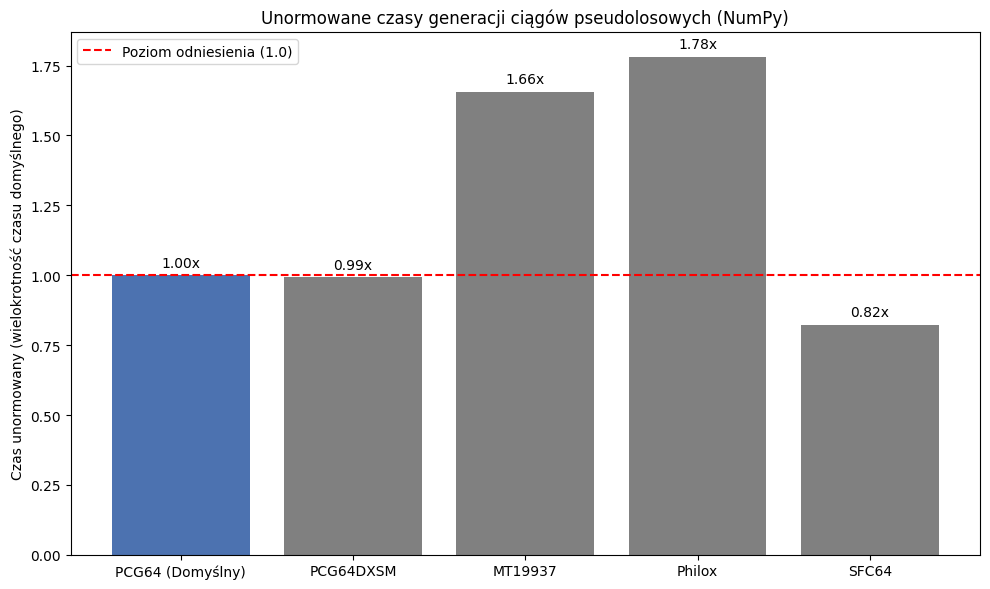

In [22]:
# ==========================================
# Definicja wszystkich generatorów
# ==========================================
generators = {
    "PCG64 (Domyślny)": np.random.Generator(np.random.PCG64(seed)),
    "PCG64DXSM": np.random.Generator(np.random.PCG64DXSM(seed)),
    "MT19937": np.random.Generator(np.random.MT19937(seed)),
    "Philox": np.random.Generator(np.random.Philox(seed)),
    "SFC64": np.random.Generator(np.random.SFC64(seed))
}

times = defaultdict(float)

print(f"Generowanie {n_numbers} liczb dla każdego algorytmu...")

# ==========================================
# Pomiar czasu
# ==========================================
for name, gen in generators.items():
    elapsed_time, _dummy = generate_numbers(name, gen, n_numbers)
    times[name] = elapsed_time
    # print(f"[{name}] Czas: {raw_times[name]:.4f} s")

# ==========================================
# Normowanie czasu do generatora domyślnego
# ==========================================
default_name = "PCG64 (Domyślny)"
default_time = times[default_name]

# Unormowany czas = czas_algorytmu / czas_domyślnego
# Wynik 1.0 oznacza czas identyczny z domyślnym. Wynik < 1.0 to generator szybszy.
normalized_times = {name: t / default_time for name, t in times.items()}

# ==========================================
# Rysowanie wykresu słupkowego
# ==========================================
plt.figure(figsize=(10, 6))

names = list(normalized_times.keys())
values = list(normalized_times.values())

# Kolorowanie: Domyślny na niebiesko, reszta na szaro
colors = ['#4C72B0' if name == default_name else '#808080' for name in names]

bars = plt.bar(names, values, color=colors)

# Rysowanie linii odniesienia na poziomie 1.0 (czas generatora domyślnego)
plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Poziom odniesienia (1.0)')

plt.ylabel('Czas unormowany (wielokrotność czasu domyślnego)')
plt.title('Unormowane czasy generacji ciągów pseudolosowych (NumPy)')
plt.legend()

# Wypisywanie wartości nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}x', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Wnioski końcowe
- Testy geometryczne (struktura przestrzenna par) są szybkim i intuicyjnym sposobem na wychwycenie trywialnych wad generatorów kongruencyjnych. Algorytm Wichmanna-Hilla zdaje ten podstawowy test, nie tworząc widocznych gołym okiem struktur w 2D.
- Klasyczny Mersenne Twister (MT19937), choć wciąż powszechnie używany, ustępuje pod względem wydajności obliczeniowej i zajętości pamięci nowszym rozwiązaniom takim jak rodzina PCG czy SFC.
- W zaawansowanych symulacjach Monte Carlo, gdzie losuje się miliardy liczb, wybór odpowiedniego silnika (np. zmiana z MT19937 na SFC64) może znacząco skrócić czas wykonywania programu. Z kolei do obliczeń rozproszonych najlepiej nadają się generatory z rodziny Philox.
- Testy geometryczne (struktura przestrzenna par) są szybkim i intuicyjnym sposobem na wychwycenie trywialnych wad generatorów kongruencyjnych. Algorytm Wichmanna-Hilla zdaje ten podstawowy test, nie tworząc widocznych gołym okiem struktur w 2D.